# Exploration: turbofan engine remaining useful life (RUL)

Starting point for exploring the data before building out `src/mlops_project`.
This notebook deliberately stops at "does a basic approach work at all" --
from here, it's up to you to dig further: which sensors actually carry
signal, whether the training target could be defined better, how to split
data for evaluation without leaking information between engines, which
model and hyperparameters work best, and so on.

We work with the **FD001** subset here: single operating condition, single
fault mode -- the simplest of the four subsets provided in `data/`
(see `data/readme.txt` for a description of all four).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

pd.set_option("display.max_columns", 30)


## Load the data

Per `data/readme.txt`: 26 whitespace-separated columns, no header -- unit
number, cycle, 3 operational settings, and 21 sensor measurements.

In [2]:
index_cols = ["unit_number", "time_cycles"]
setting_cols = ["setting_1", "setting_2", "setting_3"]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
col_names = index_cols + setting_cols + sensor_cols

train = pd.read_csv("data/train_FD001.txt", sep=r"\s+", header=None,
                     names=col_names, usecols=range(len(col_names)))

print("shape:", train.shape)
print("number of engines:", train.unit_number.nunique())
train.head()


shape: (20631, 26)
number of engines: 100


   unit_number  time_cycles  setting_1  setting_2  setting_3  sensor_1  \
0            1            1    -0.0007    -0.0004      100.0    518.67   
1            1            2     0.0019    -0.0003      100.0    518.67   
2            1            3    -0.0043     0.0003      100.0    518.67   
3            1            4     0.0007     0.0000      100.0    518.67   
4            1            5    -0.0019    -0.0002      100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  sensor_8  \
0    641.82   1589.70   1400.60     14.62     21.61    554.36   2388.06   
1    642.15   1591.82   1403.14     14.62     21.61    553.75   2388.04   
2    642.35   1587.99   1404.20     14.62     21.61    554.26   2388.08   
3    642.35   1582.79   1401.87     14.62     21.61    554.45   2388.11   
4    642.37   1582.85   1406.22     14.62     21.61    554.00   2388.06   

   sensor_9  sensor_10  sensor_11  sensor_12  sensor_13  sensor_14  sensor_15  \
0   9046.19        1.3 

In [3]:
train.describe().T


               count         mean           std        min        25%  \
unit_number  20631.0    51.506568  2.922763e+01     1.0000    26.0000   
time_cycles  20631.0   108.807862  6.888099e+01     1.0000    52.0000   
setting_1    20631.0    -0.000009  2.187313e-03    -0.0087    -0.0015   
setting_2    20631.0     0.000002  2.930621e-04    -0.0006    -0.0002   
setting_3    20631.0   100.000000  0.000000e+00   100.0000   100.0000   
sensor_1     20631.0   518.670000  0.000000e+00   518.6700   518.6700   
sensor_2     20631.0   642.680934  5.000533e-01   641.2100   642.3250   
sensor_3     20631.0  1590.523119  6.131150e+00  1571.0400  1586.2600   
sensor_4     20631.0  1408.933782  9.000605e+00  1382.2500  1402.3600   
sensor_5     20631.0    14.620000  5.329200e-15    14.6200    14.6200   
sensor_6     20631.0    21.609803  1.388985e-03    21.6000    21.6100   
sensor_7     20631.0   553.367711  8.850923e-01   549.8500   552.8100   
sensor_8     20631.0  2388.096652  7.098548e-02  23

## Take a look at one engine's sensors over time

Each engine runs from "healthy" to failure. Let's see what a couple of
sensors look like across one engine's lifetime.

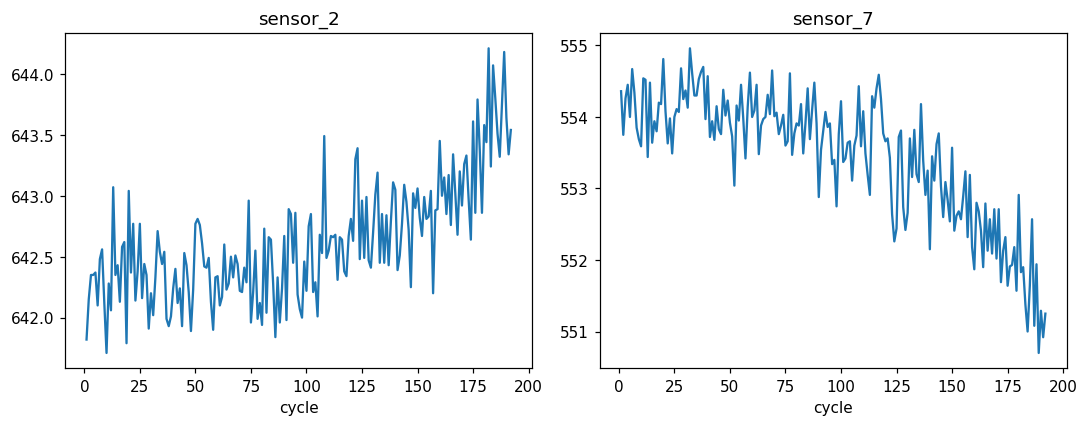

In [4]:
example = train[train.unit_number == 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(example.time_cycles, example.sensor_2)
axes[0].set_title("sensor_2")
axes[1].plot(example.time_cycles, example.sensor_7)
axes[1].set_title("sensor_7")
for ax in axes:
    ax.set_xlabel("cycle")
plt.tight_layout()
plt.show()


Try a few other sensors here too -- some will show a clear trend as the
engine approaches failure, and some may show none at all. Worth thinking
about which is which, and why that matters for building a model.

## A first, very rough target and model

To predict *remaining* useful life, we need a target: for the training
data (which runs every engine to failure), a simple starting definition is

```
RUL = (last cycle recorded for this engine) - (current cycle)
```

This is not necessarily the best definition to train on -- just a starting
point to get an end-to-end pipeline working.

In [5]:
train["RUL"] = train.groupby("unit_number")["time_cycles"].transform("max") - train["time_cycles"]
train[["unit_number", "time_cycles", "RUL"]].head()


   unit_number  time_cycles  RUL
0            1            1  191
1            1            2  190
2            1            3  189
3            1            4  188
4            1            5  187

Now a quick baseline: every setting and sensor column as a feature (no
selection yet), a plain random split, and a default-hyperparameter
scikit-learn model, just to see whether there's a learnable signal at all
before investing more effort.

**Worth thinking about**: rows from the same engine are highly correlated
(adjacent cycles look nearly identical) -- is a random row-wise split
actually a fair way to evaluate this?

In [6]:
feature_cols = setting_cols + sensor_cols

X_train, X_val, y_train, y_val = train_test_split(
    train[feature_cols], train["RUL"], test_size=0.2, random_state=0
)

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)

val_predictions = model.predict(X_val)
print("validation RMSE:", root_mean_squared_error(y_val, val_predictions))


validation RMSE: 40.82029843363828


## Where to go from here

This is a minimal starting point, not a finished approach. Some things
worth exploring further:

- Are all 24 feature columns actually useful? Are any constant / near-constant?
- Is the raw `RUL = max_cycle - cycle` target the best thing to train on?
- Is a random row-wise split a fair way to evaluate, given rows from the
  same engine are correlated?
- How does this perform against the real held-out test set
  (`data/test_FD001.txt` + `data/RUL_FD001.txt`), rather than just a
  validation split carved out of the training data?
- Which model and hyperparameters work best? (Optuna is a natural fit for
  this once you're ready -- `uv add optuna`.)

Once you're happy with an approach, move the logic into
`src/mlops_project` (`model.py` for the model itself, `train.py` for the
training entry point, and any new modules you'd like for shared
preprocessing) so it can be trained and registered with MLflow -- see the
project README.